#Data Science for Business - Group Project
#####Iñigo Ocampo de Vecchi
#####Carlos Alejandro Arroyo Cortés
#####Ludovic Delot Bravo
#####Jimena Manola Dolores Ramos



# Modeling Ferrari Stock Returns Using Market Indicators





# Data cleaning & processing

## Load the dataset

In [1]:
#Import libraries
import pandas as pd

#Upload a CSV file from our computer
from google.colab import files
uploaded = files.upload()

#Read our database containing the stock price for Ferrari
df = pd.read_csv("Ferrari History Stock Data.csv")

#Print the first rows to verify that the data uploaded correctly
print(df.head())

Saving Ferrari History Stock Data.csv to Ferrari History Stock Data.csv
         Date      Close       High        Low       Open    Volume
0  2015-10-21  50.845524  56.364575  50.845524  55.467844  22498800
1  2015-10-22  52.463337  53.803811  51.492650  52.759165   4545100
2  2015-10-23  52.121284  53.618915  52.019593  53.406289   1967600
3  2015-10-26  50.864014  52.694452  50.420271  52.694452   1466300
4  2015-10-27  49.782391  50.836283  45.631549  50.660632   5949200


### Explanation of the dataset

This dataset contains historical stock market data for Ferrari, covering daily trading activity from October 2015 to February 2026. Ferrari engages in design, engineering, production, and sale of luxury performance sports cars worldwide.

### Variables

##### Date: Trading date of the stock record
##### Close: Stock price at market closing, adjusted for splits
##### High: Highest trading price reached during the day
##### Low: Lowest trading price recorded during the day
##### Open: Stock price at market opening
##### Volume: Total number of Ferrari shares traded during the day



## Handle Missing values, Outliers & Inconsistencies

In [2]:
#We created a dataset to check null values. It returns the sum of null values per variable its percentage given the total number of observations
null_summary = pd.DataFrame({
    'Null_Count': df.isnull().sum(),
    'Null_Percentage': (df.isnull().sum() / len(df)) * 100
})

#Visualize the results
null_summary

,Null_Count,Null_Percentage
Date,0,0.0
Close,0,0.0
High,0,0.0
Low,0,0.0
Open,0,0.0
Volume,0,0.0


We observe that there are no missing values in any of the variables. This is consistent with the fact that the dataset was obtained directly from Kaggle, where financial datasets are typically well-structured and clean. Additionally, financial market data is generally easy to access because it is publicly available. Regarding potential outliers and inconsistencies, these will be examined in the following section through exploratory data analysis. However, it is important to note that extreme values may naturally occur in financial markets due to volatility and speculative behavior. Furthermore, since the dataset contains daily observations, stock prices may fluctuate significantly in response to news events or corporate actions.


## Transform data into a structured format suitable for analysis

In [3]:
#Verify the name of the variables
df.columns

#Make sure that our variable date has the correct format
df["Date"] = pd.to_datetime(df["Date"])

#Verify the class of the variables
df.dtypes

,0
Date,datetime64[ns]
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


We verified the data types. The Date variable is stored as datetime64, price variables (Open, High, Low, Close) as float64, and Volume as int64. Therefore, the dataset is correctly formatted and ready for further analysis.

### Create new variables for the analysis

In [4]:
#Import library
import numpy as np

#Calculate log returns using the closing price
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

#Calculate rolling volatility using a 10 days period
df["volatility_10"] = df["log_return"].rolling(window=10).std()

#Calculate 20-day Moving Average as a momentum factor
df["momentum_20"] = df["Close"].rolling(window=20).mean()

#Remove rows with NA values created by rolling calculations
df = df.dropna()


### Justification of additional variables
We created additional financial indicators to enrich the dataset for the subsequent analysis. First, daily logarithmic returns were calculated using closing prices, allowing the analysis of relative price changes over time. Next, a 10-day rolling volatility measure was computed as the standard deviation of log returns, capturing short-term fluctuations in the stock price. Finally, a 20-day moving average of the closing price was also calculated to represent a momentum indicator and identify potential price trends.

### Description of the new variables

- **Log Returns (`log_return`)** measure the daily percentage change in price using a logarithmic transformation. Log returns are widely used in finance because they make returns easier to analyze statistically and help stabilize variance in time-series models.

- **10-Day Rolling Volatility (`volatility_10`)** measures the standard deviation of log returns over the last 10 trading days. This captures **short-term market risk and uncertainty**, allowing the model to understand whether the stock is currently in a stable or turbulent period.

- **20-Day Moving Average (`momentum_20`)** represents the average closing price over approximately one trading month (about 20 trading days). This variable captures **momentum or trend**, helping the model detect whether the stock price is generally moving upward or downward.



## Perform exploratory data analysis (EDA) to understand key trends and patterns.

In [5]:
#Provide a summary of the structure of the database
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2579 entries, 19 to 2597
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           2579 non-null   datetime64[ns]
 1   Close          2579 non-null   float64       
 2   High           2579 non-null   float64       
 3   Low            2579 non-null   float64       
 4   Open           2579 non-null   float64       
 5   Volume         2579 non-null   int64         
 6   log_return     2579 non-null   float64       
 7   volatility_10  2579 non-null   float64       
 8   momentum_20    2579 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 201.5 KB


Our dataset contains 2,579 observations and 9 variables. We confirmed that there are no missing values. The data types are appropriate for the analysis. The dataset is now properly structured and ready for further exploratory analysis and modeling.


In [6]:
#Obtain the descriptive statistics of the variable
df.describe()

,Date,Close,High,Low,Open,Volume,log_return,volatility_10,momentum_20
count,2579,2579.000000,2579.000000,2579.000000,2579.000000,2.579000e+03,2579.000000,2579.000000,2579.000000
mean,2021-01-01 14:41:05.141527808,213.359684,215.093459,211.615170,213.349595,4.550942e+05,0.000807,0.016887,212.212313
min,2015-11-17 00:00:00,29.582851,30.026594,29.268533,29.850947,5.380000e+04,-0.162392,0.003655,34.301316
25%,2018-06-11 12:00:00,114.559639,115.333362,113.325989,114.527017,2.467500e+05,-0.008727,0.011555,114.583275
50%,2020-12-31 00:00:00,186.504532,188.677300,184.663654,186.675909,3.486000e+05,0.000990,0.014759,186.704456
75%,2023-07-26 12:00:00,298.368057,300.236088,296.145147,297.687876,5.162000e+05,0.010300,0.019137,297.612453
max,2026-02-20 00:00:00,517.650024,519.099976,514.830017,515.000000,7.485100e+06,0.118528,0.076068,500.004503
std,NaN,131.797844,132.741470,130.835177,131.804694,4.197606e+05,0.019022,0.008954,131.589697


### Count
The dataset contains 2,579 observations for all variables.

### Mean
The average closing price of Ferrari’s stock during the sample period is approximately 213 USD, with similar averages for the opening, high, and low prices. The average log return is close to zero (0.08%), which is typical in financial markets where daily returns fluctuate around a small mean. Additionally, the average 10-day volatility is around 1.69%, reflecting moderate short-term price fluctuations.

### Minimum
The minimum closing price observed in the dataset is approximately 29.58 USD, reflecting the earlier trading periods in the sample. The lowest log return recorded is around −16.2%, indicating a significant negative daily movement in the stock price. The minimum volatility value is relatively low, suggesting periods of very stable price behavior.

### Quartile 1
The first quartile indicates that 25% of the observations have closing prices below approximately 115 USD. The log return at this percentile is slightly negative at -0.87%, which suggests that a quarter of the daily returns fall below small negative values.

### Quartile 2
The median closing price is approximately 187 USD, which represents the midpoint of the price distribution. The median log return is very close to zero, indicating that positive and negative daily price movements are relatively balanced over the sample period.

### Quartile 3
The third quartile shows that 75% of the observations have closing prices below approximately 298 USD, reflecting the substantial growth in Ferrari’s stock price over time. The corresponding log return at this percentile indicates that a large portion of the daily returns are moderately positive.

### Maximum
The highest closing price observed in the dataset is approximately 518 USD. The maximum daily log return is about 11.85%, indicating that the stock experienced notable positive price jumps during certain trading days.

### Standard Deviation
The standard deviation of the closing price is approximately 132 USD, indicating considerable variability in the stock price across the sample period. Meanwhile, the standard deviation of the log returns is about 1.9%, which is consistent with the typical level of daily volatility observed in equity markets.



### Visualization of Stock behaviour over time

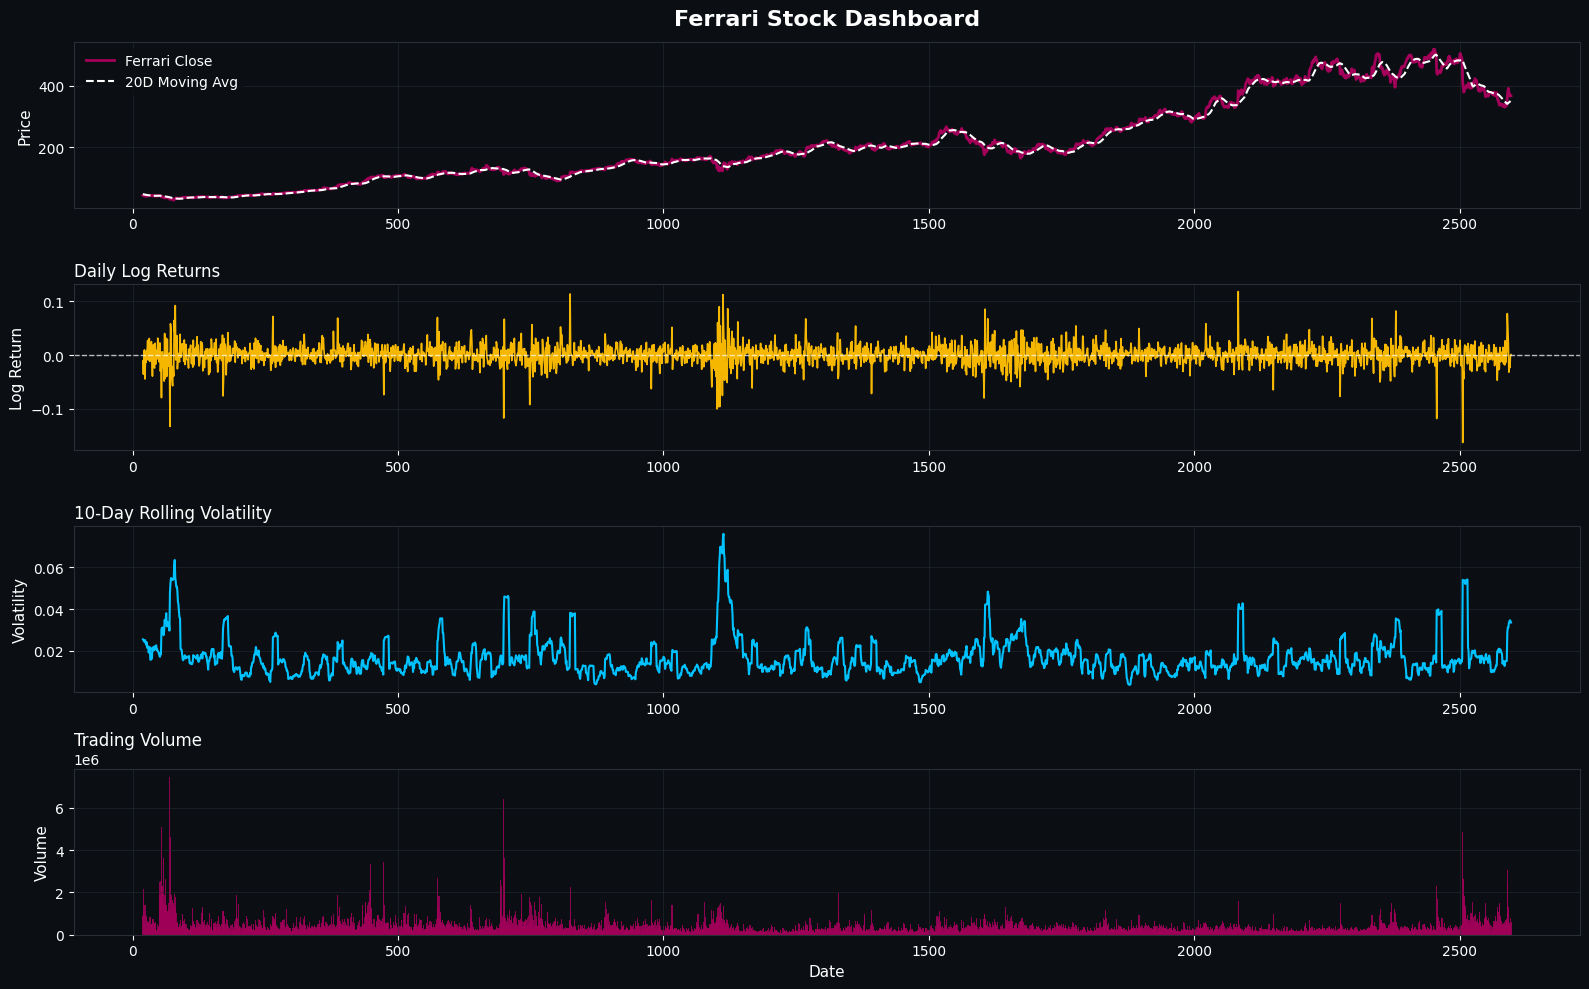

In [7]:
#Import library to create visualizations
import matplotlib.pyplot as plt

#Assign colors for our different visualizations
bg_color = "#0b0f14"
grid_color = "#2a2f36"
text_color = "white"
price_color = "#A30059"
vol_color = "#00c2ff"
return_color = "#f5b700"
ma_color = "#ffffff"

#Create 4 subplots & assign the same horizontal axis
fig = plt.figure(figsize=(16, 10), facecolor=bg_color)
ax1 = plt.subplot(4, 1, 1, facecolor=bg_color)
ax2 = plt.subplot(4, 1, 2, sharex=ax1, facecolor=bg_color)
ax3 = plt.subplot(4, 1, 3, sharex=ax1, facecolor=bg_color)
ax4 = plt.subplot(4, 1, 4, sharex=ax1, facecolor=bg_color)

#Visualization of Ferrari's closing price vs 20-day moving average
ax1.plot(df.index, df["Close"], color=price_color, linewidth=2, label="Ferrari Close")
ax1.plot(df.index, df["momentum_20"], color=ma_color, linewidth=1.5, linestyle="--", label="20D Moving Avg")
ax1.set_title("Ferrari Stock Dashboard", color=text_color, fontsize=16, fontweight="bold", pad=12)
ax1.set_ylabel("Price", color=text_color, fontsize=11)
ax1.legend(facecolor=bg_color, edgecolor="none", labelcolor=text_color, loc="upper left")
ax1.grid(True, color=grid_color, alpha=0.5)

#Visualization of log-returns over time
ax2.plot(df.index, df["log_return"], color=return_color, linewidth=1.2)
ax2.axhline(0, color="white", linewidth=1, linestyle="--", alpha=0.7)
ax2.set_ylabel("Log Return", color=text_color, fontsize=11)
ax2.set_title("Daily Log Returns", color=text_color, fontsize=12, loc="left")
ax2.grid(True, color=grid_color, alpha=0.5)

#Visualization of rolling volatility during a 10-day period
ax3.plot(df.index, df["volatility_10"], color=vol_color, linewidth=1.5)
ax3.set_ylabel("Volatility", color=text_color, fontsize=11)
ax3.set_title("10-Day Rolling Volatility", color=text_color, fontsize=12, loc="left")
ax3.grid(True, color=grid_color, alpha=0.5)

#Visualization for trading volume
ax4.bar(df.index, df["Volume"], color=price_color, alpha=0.85, width=2)
ax4.set_ylabel("Volume", color=text_color, fontsize=11)
ax4.set_title("Trading Volume", color=text_color, fontsize=12, loc="left")
ax4.grid(True, color=grid_color, alpha=0.5)

#Styling of axes, final formatting & display of visualizations
for ax in [ax1, ax2, ax3, ax4]:
    ax.tick_params(axis="x", colors=text_color)
    ax.tick_params(axis="y", colors=text_color)
    for spine in ax.spines.values():
        spine.set_color(grid_color)
plt.xlabel("Date", color=text_color, fontsize=11)
plt.tight_layout()
plt.show()

### Closing price vs 20-day moving average
The first chart shows the evolution of Ferrari’s closing stock price over the sample period together with the 20-day moving average, which acts as a momentum indicator. Overall, the stock displays a clear long-term upward trend, increasing from levels below 50 USD in the earlier observations to values above 450 USD in the later part of the sample. This indicates a strong appreciation of Ferrari’s stock over time.

The 20-day moving average closely follows the price series but smooths short-term fluctuations, making the underlying trend easier to observe. Periods where the price moves significantly above the moving average suggest strong upward momentum, while moments when the price approaches or falls below the moving average may indicate short-term corrections.

### Daily log-returns
The second chart presents the daily logarithmic returns of Ferrari’s stock. As expected in financial time series, the returns fluctuate around zero, indicating that positive and negative price movements occur frequently over time.

Most daily returns remain relatively small; however, several extreme spikes can be observed, representing days with unusually large positive or negative price movements. These spikes reflect periods of increased market volatility and may be associated with market reactions to news, macroeconomic events, or firm-specific announcements.

### 10-day rolling volatility
The third chart shows the 10-day rolling volatility of Ferrari’s stock returns, which measures how much the stock price fluctuates over short periods. Most of the time, volatility remains relatively stable at low levels, indicating periods of moderate price variability.

However, several sharp spikes in volatility can be observed throughout the sample. These spikes represent moments when the stock experienced unusually large price movements over consecutive days. Such periods typically occur when markets react strongly to major news, earnings announcements, macroeconomic events, or broader market shocks.

### Trading volume
The fourth chart displays the daily trading volume of Ferrari’s stock, representing the number of shares traded each day. In most periods, trading activity remains relatively stable, with moderate daily volumes.

Nevertheless, the chart shows several large spikes in trading volume, indicating days with significantly higher market participation. These spikes may correspond to important events such as earnings releases, major corporate announcements, or broader market reactions, which typically attract increased investor attention and trading activity.

### Checking Normality

### Histogram

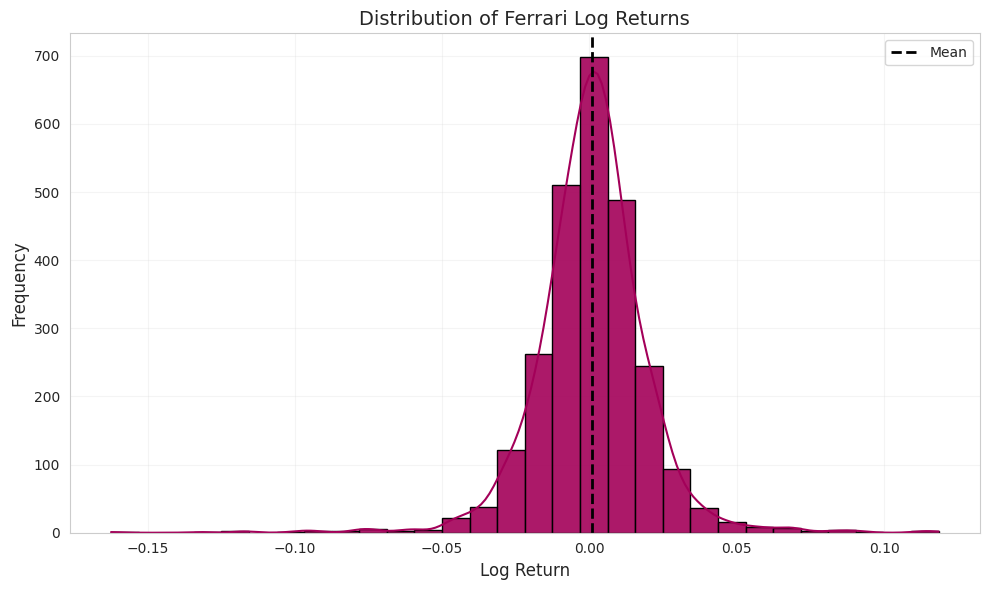

In [8]:
#Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Set visualization style
sns.set_style("whitegrid")

#Set color and size for the visualization
magenta_color = "#A30059"
plt.figure(figsize=(10,6))

#Create the histogram
sns.histplot(
    df['log_return'].dropna(),
    bins=30,
    kde=True,
    color=magenta_color,
    edgecolor="black",
    alpha=0.9
)

#Title and axis labels
plt.title("Distribution of Ferrari Log Returns", fontsize=14)
plt.xlabel("Log Return", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

#Mean reference line in the histogram
plt.axvline(df['log_return'].mean(), color="black", linestyle="--", linewidth=2, label="Mean")

#Final formatting and display of the visualization
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

The histogram shows the distribution of Ferrari’s daily log-returns, we used them instead of stock prices because returns represent relative price changes and are more suitable for statistical analysis. While stock prices typically trend over time, returns fluctuate around a stable mean, making them easier to model. As shown in the histogram, most returns are concentrated around zero, indicating that daily price changes are generally small. However, the distribution is not perfectly normal, displaying negative skewness and high kurtosis. This suggests that extreme values occur more frequently than expected under a normal distribution, and that large negative returns tend to occur slightly more often or with greater magnitude than large positive returns.

## QQ-Plot

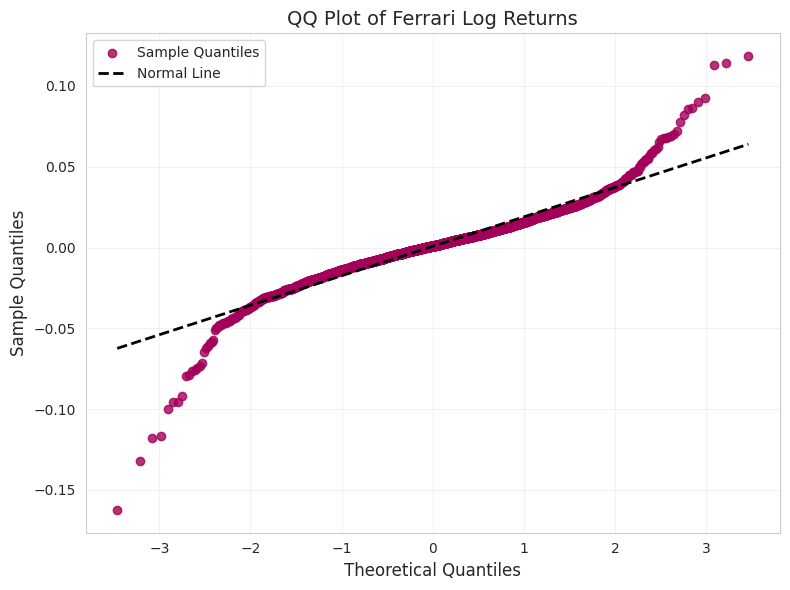

In [9]:
#Import libraries
import matplotlib.pyplot as plt
import scipy.stats as stats

#Define color and size for the visualization
magenta_color = "#A30059"
plt.figure(figsize=(8,6))

#Generate QQ plot
(res_osm, res_osr), (slope, intercept, r) = stats.probplot(df['log_return'].dropna(), dist="norm")

#Plot sample quantiles
plt.scatter(res_osm, res_osr, color=magenta_color, alpha=0.8, label="Sample Quantiles")

#Add Reference normal line
plt.plot(res_osm, slope*res_osm + intercept, color="black", linewidth=2, linestyle="--", label="Normal Line")

#Include title and labels
plt.title("QQ Plot of Ferrari Log Returns", fontsize=14)
plt.xlabel("Theoretical Quantiles", fontsize=12)
plt.ylabel("Sample Quantiles", fontsize=12)

#Final formatting & display
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

The QQ plot compares the empirical quantiles of Ferrari’s daily log returns with the theoretical quantiles of a normal distribution. If the returns were normally distributed, the points would lie closely along the reference line. However, the plot shows clear deviations from this line, particularly in the tails of the distribution. The extreme observations at both ends move away from the normal line, indicating the presence of heavy tails. This suggests that extreme positive and negative returns occur more frequently than would be expected under a normal distribution.

## Normality tests

In [10]:
#Import libraries for statistical tests
from scipy.stats import shapiro, normaltest, jarque_bera
import pandas as pd

#Save log-returns without NA to prepare data
log_returns = df['log_return'].dropna()

#Perform Normality tests
shapiro_stat, shapiro_p = shapiro(log_returns)
dagostino_stat, dagostino_p = normaltest(log_returns)
jb_stat, jb_p = jarque_bera(log_returns)

#Create summary table with results
normality_results = pd.DataFrame({
    'Test': ['Shapiro-Wilk', "D’Agostino-Pearson", 'Jarque-Bera'],
    'Statistic': [shapiro_stat, dagostino_stat, jb_stat],
    'p-value': [shapiro_p, dagostino_p, jb_p]
})

#Round numbers for readability
normality_results = normality_results.round(6)

#Styled table
styled_table = (
    normality_results.style
    .set_caption("Normality Test Results for Ferrari Log Returns")
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#A30059'),
                   ('color', 'white'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center')]},
        {'selector': 'caption',
         'props': [('font-size', '14px'),
                   ('font-weight', 'bold')]}
    ])
)

#Display results
styled_table

,Test,Statistic,p-value
0,Shapiro-Wilk,0.920339,0.000000
1,D’Agostino-Pearson,456.209761,0.000000
2,Jarque-Bera,6945.774831,0.000000


The results of the three normality tests (Shapiro-Wilk, D’Agostino-Pearson, and Jarque-Bera) show p-values equal to 0.000, which are well below the 0.05 significance level. Therefore, we reject the null hypothesis of normality for Ferrari’s daily log-returns. These results confirm the findings from the histogram and QQ plot, indicating that the return distribution deviates from normality and exhibits heavy tails, meaning that extreme returns occur more frequently than expected under a normal distribution.

# Application of data science techniques

Based on the exploratory data analysis and the statistical properties observed, the objective of our project will focus on stock price prediction using regression models. In particular, regression techniques will be applied to estimate Ferrari’s stock behavior by modeling the relationship between the target variable (closing price) and relevant explanatory factors. This approach will allow us to evaluate how well the selected variables explain variations in the stock and to assess the predictive performance of the model using appropriate evaluation metrics.

## Preparation of the model

In [11]:
#Import libraries
import pandas as pd
import numpy as np
import yfinance as yf

#Format the data and define the date index to merge datasets
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

#Ferrari variables previously created
df["ferrari_log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df["ferrari_volatility_10"] = df["ferrari_log_return"].rolling(10).std()
df["ferrari_momentum_20"] = df["Close"].rolling(20).mean()

#Use the same window as Ferrari to download data from Yahoo Finance
start = df.index.min().strftime("%Y-%m-%d")
end = (df.index.max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

#Download S&P 500 and rename variables
sp500 = yf.Ticker("^GSPC").history(start=start, end=end)[["Close"]]
sp500 = sp500.rename(columns={"Close": "sp500_close"})

#Download VIX and rename variables
vix = yf.Ticker("^VIX").history(start=start, end=end)[["Close"]]
vix = vix.rename(columns={"Close": "vix_close"})

#Remove timezone information
sp500.index = sp500.index.tz_localize(None)
vix.index = vix.index.tz_localize(None)

#Generate new variables for S&P500
sp500["sp500_log_return"] = np.log(sp500["sp500_close"] / sp500["sp500_close"].shift(1))
sp500["sp500_volatility_10"] = sp500["sp500_log_return"].rolling(10).std()
sp500["sp500_momentum_20"] = sp500["sp500_close"].rolling(20).mean()

#Generate new variables for Vix
vix["vix_log_return"] = np.log(vix["vix_close"] / vix["vix_close"].shift(1))
vix["vix_change"] = vix["vix_close"].diff()
vix["vix_volatility_10"] = vix["vix_log_return"].rolling(10).std()

#Merge everything into one base
base = df.join(sp500, how="left").join(vix, how="left")

#Forward fill market values if dates do not align perfectly
base = base.ffill()

#Keep only the variables we want for later
base = base[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "ferrari_log_return",
        "ferrari_volatility_10",
        "ferrari_momentum_20",
        "sp500_close",
        "sp500_log_return",
        "sp500_volatility_10",
        "sp500_momentum_20",
        "vix_close",
        "vix_log_return",
        "vix_change",
        "vix_volatility_10",
    ]
]

#Remove rows created by rolling windows
base = base.dropna()

# Check the final base
print(base.head())
print("\nColumns:")
print(base.columns)
print("\nShape:")
print(base.shape)

                 Open       High        Low      Close  Volume  \
Date                                                             
2015-12-15  43.385100  45.381943  43.357368  43.958267  760700   
2015-12-16  44.670106  45.271009  43.717909  44.836510  534500   
2015-12-17  44.975180  45.289497  43.468302  43.893555  547100   
2015-12-18  43.412831  43.893553  42.525347  42.858154  461200   
2015-12-21  42.756464  44.189383  42.608550  43.828842  623100   

            ferrari_log_return  ferrari_volatility_10  ferrari_momentum_20  \
Date                                                                         
2015-12-15            0.013125               0.020029            43.836237   
2015-12-16            0.019782               0.020675            43.814050   
2015-12-17           -0.021255               0.021994            43.823295   
2015-12-18           -0.023872               0.020404            43.765978   
2015-12-21            0.022396               0.021889            43.7

### Market indicators
To add relevant independent variables to the model, two key market indicators were incorporated: the S&P 500 and the VIX index. The S&P 500 represents the overall performance of the U.S. stock market and is widely used as a benchmark for general market conditions. The VIX, often referred to as the market volatility index, measures the expected volatility of the market and reflects investor uncertainty or risk perception.

### S&P500 variables
For the S&P 500, three additional variables were created. First, sp500_log_return was calculated to measure the daily relative change in the index. Second, sp500_volatility_10 was computed as the 10-day rolling standard deviation of the S&P 500 log returns, capturing short-term market volatility. Third, sp500_momentum_20 was calculated as the 20-day moving average of the S&P 500 closing price, which helps capture the short-term trend of the overall market.

### VIX variables
For the VIX, three different variables were created. First, vix_log_return was calculated to measure the daily relative change in the VIX level. Second, vix_change was created as the daily absolute difference in the VIX, capturing increases or decreases in market uncertainty from one day to the next. Third, vix_volatility_10 was computed as the 10-day rolling standard deviation of the VIX log returns, which reflects how unstable or variable market fear has been over short periods.

### Justification of variables
While similar transformations were applied to both series, the VIX variables differ slightly because the VIX represents expected market volatility rather than a stock price. Therefore, variables such as the daily change in the VIX were included to capture shifts in market uncertainty.





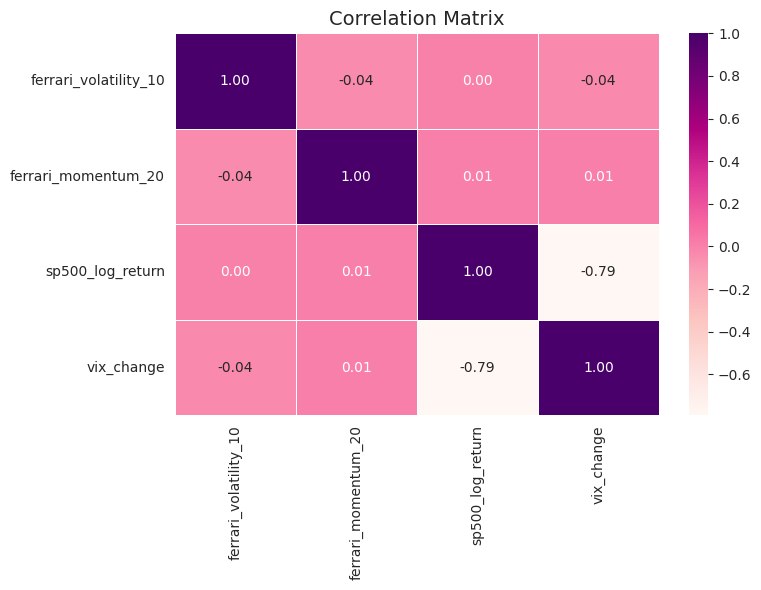

In [12]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

#Select only the variables that we want to use to build the model
corr_data = base[[
    "ferrari_volatility_10",
    "ferrari_momentum_20",
    "sp500_log_return",
    "vix_change"
]].dropna()

#Create a correlation matrix
corr_matrix = corr_data.corr()

#Visualize correlation with a Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdPu",
    fmt=".2f",
    linewidths=0.5
)

#Formatting
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

### Selection of variables for the model
For the final model, we decided to only use a subset of all the variables previously created. The selected variables are the following: ferrari_volatility_10, ferrari_momentum_20, sp500_log_return, and vix_change.

These variables capture different dimensions of the market. On one hand, we selected Ferrari specific variables (volatility and momentum) to reflect the stock’s own behavior, specifically risk and trend dynamics. On the other hand, we also included external variables such as the S&P 500 return and VIX changes to incorporate broader market performance and investor sentiment. This combination allows the model to consider both internal and external drivers of stock price movements.

It is important to note that for Ferrari's variables, we selected them over longer windows (10 and 20 days), allowing us to capture medium-term trends and risk patterns in the stock. This is relevant because Ferrari’s price dynamics are often influenced by broader corporate strategies, brand positioning, and longer-term investor expectations rather than only short-term fluctuations.

In contrast, the S&P 500 returns and VIX changes are measured on a daily basis, capturing immediate market movements and investor sentiment. This combination allows the model to integrate both short-term market signals and medium-term stock behavior, providing a more complete representation of the factors that may influence Ferrari’s price evolution.

### Correlation of variables
The correlation matrix shows that most variables exhibit very low correlations, indicating that they capture different dimensions of the market and do not provide redundant information. This is beneficial for the regression model, as it reduces the risk of multicollinearity and improves the reliability of coefficient estimates.

The only strong relationship observed is the negative correlation (-0.79) between sp500_log_return and vix_change, which is consistent with financial theory. When the market performs well, uncertainty tends to decrease, leading to a decline in the VIX, whereas negative market returns are typically associated with higher volatility expectations.

Overall, the low correlation among most variables suggests that the selected features are appropriate, as they contribute complementary information and enhance the explanatory power of the model without introducing significant multicollinearity issues.

# Model deployment & Business Implications

## Train and test the model using appropriate evaluation techniques

In [13]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Define the target variable (next-day closing price target)
base["target_price"] = base["Close"].shift(-1) #Prediction based on stock price close (not in the model)

#Select the dataset to be used for the model
model_data = base[[
    "ferrari_volatility_10",
    "ferrari_momentum_20",
    "sp500_log_return",
    "vix_change",
    "target_price"
]].dropna()

#Define dependent and independent variables
X = model_data[[
    "ferrari_volatility_10",
    "ferrari_momentum_20",
    "sp500_log_return",
    "vix_change"
]]
y = model_data["target_price"]

#Split data in train and test
split = int(len(model_data) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

#Fit the model to linear regression
model = LinearRegression()
model.fit(X_train, y_train)

#Generate predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#Evaluate performance for the train set
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

#Evaluate performance for the test set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)


# Justification of methodology

## Explain why the chosen data science technique is suitable for the dataset

The dataset was split into two subsets, using 80% of the observations for training and the remaining 20% for testing, while preserving the chronological order of the data. This approach is particularly appropriate for financial time series, as it prevents data leakage and ensures that the model is evaluated on future, unseen data.
A linear regression model was then applied due to its simplicity, interpretability, and strong theoretical foundation in finance. Linear regression allows us to quantify the relationship between the dependent variable and multiple explanatory variables, making it especially useful for understanding how different factors influence stock prices. Additionally, it serves as a reliable baseline model, providing clear insights into variable significance and model performance, which is essential before exploring more complex techniques.

## Support the justification with performance metrics

In [14]:
#Print metrics for the training set
print("Train Metrics")
print("MAE:", round(train_mae, 4))
print("RMSE:", round(train_rmse, 4))
print("R²:", round(train_r2, 4))

#Print metrics for the testing set
print("\nTest Metrics")
print("MAE:", round(test_mae, 4))
print("RMSE:", round(test_rmse, 4))
print("R²:", round(test_r2, 4))

Train Metrics
MAE: 5.4878
RMSE: 7.7731
R²: 0.9903

Test Metrics
MAE: 16.8489
RMSE: 22.1862
R²: 0.6977


### Performance Metrics
1. MAE (Mean Absolute Error)
Measures the average absolute difference between predicted and actual values. It is easy to interpret since it is expressed in the same units as the stock price. Lower values indicate better accuracy.

2. RMSE (Root Mean Squared Error)
Measures the square root of the average squared differences between predictions and actual values. It penalizes large errors more heavily than MAE, making it useful to detect models with high variance or extreme prediction mistakes.

3. R² (Coefficient of Determination)
Indicates the proportion of variance in the dependent variable explained by the model. Values closer to 1 mean a better fit, while values closer to 0 indicate poor explanatory power.

### Interpretation of performance metrics
In the training set, the model shows an extremely strong performance, with very low error values (MAE ≈ 5.49 and RMSE ≈ 7.77) and a very high R² (0.9903). However, this result must be interpreted with caution, as it reflects the model’s performance on the same data it was trained on. In this context, such a high R² is expected and does not necessarily indicate true predictive power, but rather that the model has been optimized to fit the training data very closely. Therefore, this can be considered a form of overfitting, where the model captures patterns specific to the training sample that may not generalize well to new data.

Focusing on the test set, the model achieves an R² of 0.6977, indicating that it explains approximately 70% of the variability in Ferrari’s stock price when evaluated on unseen data. Although the error metrics (MAE ≈ 16.85 and RMSE ≈ 22.19) are notably higher than in the training set, this is expected when moving from in-sample to out-of-sample performance. In the context of financial markets, where price movements are driven by a high level of noise, external shocks, and unpredictable events, achieving this level of explanatory power is relatively strong. Therefore, the model can be considered good, as it captures a substantial portion of the underlying price dynamics while maintaining a reasonable balance between accuracy and generalization.


## Interpret the results and assess their impact on business decisions

In [15]:
#Import libraries
import statsmodels.api as sm
import pandas as pd

#Add constant for intercept
X_sm = sm.add_constant(X_train)

#Fit the regression model
model_sm = sm.OLS(y_train, X_sm).fit()

#Extract coefficients and p-values
coef_table = pd.DataFrame({
    "Variable": model_sm.params.index,
    "Coefficient": model_sm.params.values,
    "p-value": model_sm.pvalues.values
})

#Print results
print("\nRegression Results:")
print(coef_table.round(4))
print("\nIntercept:", model_sm.params["const"])


Regression Results:
                Variable  Coefficient  p-value
0                  const       2.5816   0.0000
1  ferrari_volatility_10    -111.6585   0.0000
2    ferrari_momentum_20       1.0048   0.0000
3       sp500_log_return     193.3286   0.0000
4             vix_change       0.4788   0.0009

Intercept: 2.58164184880102


### Interpretation of coefficients

The regression results show that all variables are statistically significant, as their p-values are below 0.05 significance level, indicating strong evidence that each variable contributes meaningfully to explaining Ferrari’s stock price.

The coefficient for ferrari_volatility_10 (-111.66) is negative, suggesting that higher short-term volatility is associated with lower future stock prices. This makes sense since increased volatility often reflects higher uncertainty and risk, which can negatively impact investor confidence.

The coefficient for ferrari_momentum_20 (1.00) is positive, indicating that upward trends in Ferrari’s stock price tend to persist, meaning that higher momentum is associated with higher future prices.

The sp500_log_return (193.33) has a strong positive coefficient, implying that positive movements in the overall market are strongly associated with increases in Ferrari’s stock price.

Finally, vix_change (0.48) shows a small but positive effect. While this may seem counterintuitive, it suggests that increases in market volatility may coincide with slight increases in Ferrari’s stock price, potentially reflecting periods where certain sectors or high-value brands behave differently from the broader market.

### Impact on business decisions
From a business and investment perspective, these results provide valuable insights into the drivers of Ferrari’s stock price. The strong influence of market performance (S&P 500) suggests that external conditions play a key role, meaning that investment strategies should consider overall market trends when evaluating Ferrari’s stock. The negative impact of volatility indicates that periods of uncertainty may pose risks, reinforcing the importance of risk management. Additionally, the positive momentum effect suggests that recent trends can be informative for short-term decision-making. Overall, the model highlights that both internal stock dynamics and external market factors should be considered when making investment decisions, supporting more informed and data-driven strategies.

##Suggest actionable insights and recommendations based on the findings.

Based on the model results, one key actionable insight is the strong influence of overall market conditions, particularly the S&P 500 returns, on Ferrari’s stock price. This suggests that investors and analysts should closely monitor broader market trends when making decisions related to Ferrari. In periods of positive market performance, there may be greater opportunities to invest or increase exposure, while during market downturns, a more cautious approach may be advisable. Additionally, the negative relationship between volatility and future prices indicates that higher uncertainty may signal potential downside risk, reinforcing the importance of incorporating risk indicators into investment strategies.

Another important insight comes from the role of momentum, which shows that recent price trends tend to persist over time. This supports the use of trend-following strategies, where investors can leverage recent upward movements to anticipate short-term price increases. From a business perspective, this also suggests that maintaining positive market sentiment and consistent performance can have a reinforcing effect on stock valuation.

# Validation & Interpretation of Results

## Visualize results through graphs, dashboards, or reports.

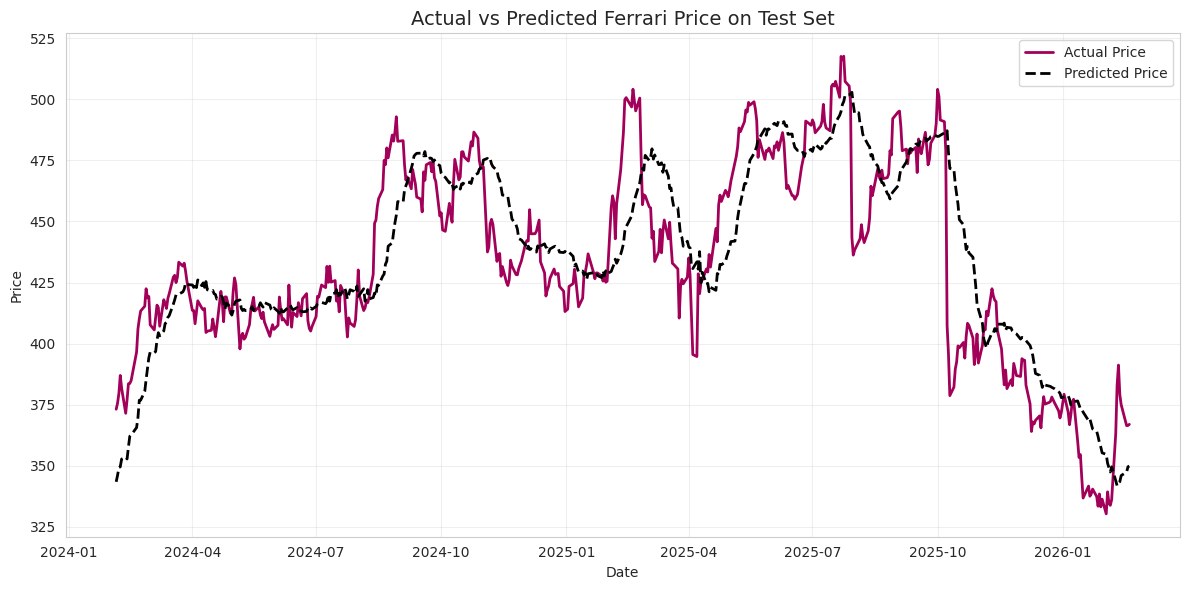

In [16]:
#Create results table
results = pd.DataFrame({
    "Actual_Price": y_test,
    "Predicted_Price": y_test_pred
}, index=y_test.index)

#Plot actual vs predicted on test set
plt.figure(figsize=(12, 6))
plt.plot(results.index, results["Actual_Price"], label="Actual Price", linewidth=2, color="#A30059")
plt.plot(results.index, results["Predicted_Price"], label="Predicted Price", linewidth=2, color="black", linestyle="--")
plt.title("Actual vs Predicted Ferrari Price on Test Set", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The graph presents a comparison between the actual Ferrari stock prices and the predicted values generated by the model over the test period. The solid magenta line represents the real observed prices, while the dashed black line corresponds to the model’s predictions.

Overall, the model is able to capture the general trend and direction of Ferrari’s stock price, as the predicted line follows the upward and downward movements of the actual series reasonably well. This indicates that the selected variables contain meaningful information about the underlying dynamics of the stock. However, the model tends to produce a smoother series, failing to fully capture sharp fluctuations and sudden changes in price. This is particularly evident during periods of high volatility, where the actual price shows abrupt movements that the model underestimates.

Additionally, the model shows some lag in reaction, meaning that it adjusts more slowly to rapid changes in the market. For example, during sharp drops or spikes, the predicted values do not immediately reflect the magnitude of the movement. This behavior is typical of linear models, which rely on stable relationships and may struggle to fully capture short-term shocks or extreme events in financial markets.

In conclusion, the model performs well in identifying overall price trends and medium-term dynamics, but it is less effective in capturing short-term volatility and extreme movements. This suggests that while the model is useful for understanding general patterns in Ferrari’s stock behavior, it has limitations when it comes to predicting sudden market changes or high-frequency fluctuations.


## Discuss potential business applications and limitations of the model.

### Business applications
The model can be applied as a decision-support tool for investors and financial analysts by providing insights into the key drivers of Ferrari’s stock price. By incorporating both firm specific indicators (volatility and momentum) and broader market variables (S&P 500 returns and VIX changes), the model helps identify how internal performance and external market conditions jointly influence price movements. This can support short-term investment strategies, such as timing entry and exit points based on market trends or momentum signals. Additionally, the model can be useful for portfolio management, as it highlights the sensitivity of Ferrari’s stock to overall market dynamics, allowing investors to better assess risk exposure and adjust their positions accordingly.

### Limitations
Despite its usefulness, the model has a couple of limitations. First, it relies on a linear framework, which may not fully capture complex and nonlinear relationships present in financial markets. Second, while the model performs well in identifying general trends, it struggles to accurately predict sharp fluctuations and extreme price movements, as observed in the visualization of actual versus predicted values. Third, the model only includes a limited set of variables and does not account for other important factors such as macroeconomic indicators, company-specific news, or unexpected external shocks, all of which can significantly impact stock prices. Therefore, while the model provides valuable insights, its predictions should be interpreted with caution and complemented with additional analysis.
